# NumPy Basics: Arrays and Vectorized Computation

In [1]:
import numpy as np
np.random.seed(12345)
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 6))
np.set_printoptions(precision=4, suppress=True)

In [2]:
import numpy as np
my_arr = np.arange(1000000)
my_list = list(range(1000000))

In [3]:
%time for _ in range(10): my_arr2 = my_arr * 2
%time for _ in range(10): my_list2 = [x * 2 for x in my_list]

Wall time: 17.8 ms
Wall time: 761 ms


## The NumPy ndarray: A Multidimensional Array Object

In [4]:
import numpy as np
# Generate some random data
data = np.random.randn(2, 3)
data

array([[-0.2047,  0.4789, -0.5194],
       [-0.5557,  1.9658,  1.3934]])

In [5]:
data * 10
data + data

array([[-0.4094,  0.9579, -1.0389],
       [-1.1115,  3.9316,  2.7868]])

In [6]:
data.shape
data.dtype

dtype('float64')

### Creating ndarrays

In [7]:
data1 = [6, 7.5, 8, 0, 1]
arr1 = np.array(data1)
arr1

array([6. , 7.5, 8. , 0. , 1. ])

In [8]:
arr1.shape

(5,)

In [9]:
data2 = [[1, 2, 3, 4], [5, 6, 7, 8]]
arr2 = np.array(data2)
arr2

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [10]:
print(arr2.ndim)
print(arr2.shape)

2
(2, 4)


In [11]:
arr1.dtype

dtype('float64')

In [12]:
arr2.dtype

dtype('int32')

In [13]:
np.zeros(6)

array([0., 0., 0., 0., 0., 0.])

In [14]:
np.zeros((1, 6)) # กลายเป็น list ที่มี element คือ np.zeros(6)

array([[0., 0., 0., 0., 0., 0.]])

In [15]:
np.zeros((3, 6)) # กลายเป็น list ที่มี element คือ np.zeros(6)

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [16]:
np.zeros((2, 3, 6)) # กลายเป็น list ที่มี element คือ np.zeros((3,6))

array([[[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]]])

In [17]:
np.ones_like(np.zeros((2, 3, 6)))

array([[[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]],

       [[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]]])

In [18]:
np.arange(15)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

### Data Types for ndarrays

In [19]:
arr1 = np.array([1, 2, 3], dtype=np.float64)
arr2 = np.array([1, 2, 3], dtype=np.int32)
arr1.dtype
arr2.dtype

dtype('int32')

You can explicitly convert or cast an array from one dtype to another using ndarray’s `astype` method:

In [20]:
arr = np.array([1, 2, 3, 4, 5])
print(arr.dtype)
float_arr = arr.astype(np.float64)
print(float_arr.dtype)

int32
float64


In this example, integers were cast to floating point. If I cast some floating-point
numbers to be of integer dtype, the decimal part will be truncated:

In [21]:
arr = np.array([3.7, -1.2, -2.6, 0.5, 12.9, 10.1])
arr

array([ 3.7, -1.2, -2.6,  0.5, 12.9, 10.1])

In [22]:
arr.astype(np.int32)

array([ 3, -1, -2,  0, 12, 10])

In [23]:
numeric_strings = np.array(['1.25', '-9.6', '42'], dtype=np.string_)
numeric_strings

array([b'1.25', b'-9.6', b'42'], dtype='|S4')

In [24]:
#ลองเอง
print(list(b'1.25'))
[chr(byte) for byte in b'1.25']

[49, 46, 50, 53]


['1', '.', '2', '5']

In [25]:
#numeric_strings.astype(float) --> same result
numeric_strings.astype(np.float64)

array([ 1.25, -9.6 , 42.  ])

In [26]:
#ลองเอง
fixed_size_strings = np.array(['aaa', '1234', 'cc'], dtype='S3')
fixed_size_strings

array([b'aaa', b'123', b'cc'], dtype='|S3')

In [27]:
#ลองเอง
var_size_strings = np.array(['aaa', '1234', 'cc'], dtype=np.string_)
var_size_strings

array([b'aaa', b'1234', b'cc'], dtype='|S4')

In [28]:
#ลองเอง
unicode_strings = np.array(['aaa', '1234', 'cc'], dtype='U3')
unicode_strings # ไม่ใช่ byte string อีกต่อไป แต่ตัดที่ 3

array(['aaa', '123', 'cc'], dtype='<U3')

In [29]:
int_array = np.arange(10)
calibers = np.array([.22, .270, .357, .380, .44, .50], dtype=np.float64)
int_array.astype(calibers.dtype) # np.float64 ตาม type ของ calibers

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [30]:
empty_uint32 = np.empty(8, dtype='u4')
empty_uint32

array([         0, 1075314688,          0, 1075707904,          0,
       1075838976,          0, 1072693248], dtype=uint32)

In [31]:
#ลองเอง
np.ones((2,2))

array([[1., 1.],
       [1., 1.]])

In [32]:
#ลองเอง
np.ones((2,2), dtype='i4')

array([[1, 1],
       [1, 1]])

### Arithmetic with NumPy Arrays

In [33]:
arr = np.array([[1., 2., 3.], [4., 5., 6.]])
arr
arr * arr
arr - arr

array([[0., 0., 0.],
       [0., 0., 0.]])

In [34]:
1 / arr
arr ** 0.5

array([[1.    , 1.4142, 1.7321],
       [2.    , 2.2361, 2.4495]])

In [35]:
arr2 = np.array([[0., 4., 1.], [7., 2., 12.]])
arr2
arr2 > arr

array([[False,  True, False],
       [ True, False,  True]])

### Basic Indexing and Slicing

In [36]:
arr = np.arange(10)
arr
arr[5]
arr[5:8]

#As you can see, if you assign a scalar value to a slice, as in arr[5:8] = 12, the value is
#propagated (or broadcasted henceforth) to the entire selection.
arr[5:8] = 12
arr

array([ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9])

An important first distinction
from Python’s built-in lists is that array slices are views on the original array.
This means that the data is not copied, and any modifications to the view will be
reflected in the source array.

In [37]:
arr_slice = arr[5:8] #A
arr_slice

array([12, 12, 12])

In [38]:
arr_slice[1] = 12345 #B
arr

array([    0,     1,     2,     3,     4,    12, 12345,    12,     8,
           9])

In [39]:
#ลองเอง ลองกับ List
l = list(range(5))
l_slice = l[1:3] #A
l_slice[0] = 10 #B
l

[0, 1, 2, 3, 4]

In [40]:
#search
l1 = [[0, 1], [1, 1], [2, 0], [3, 1], [4, 0]]
print(l1)

# Things that are copied are 'references'
l1_slice = l1[1:3]
l1_slice[0].append(1)
print(l1)

# l1_slice ไม่ได้เป็น view เพระการ modify content(ซึ่งก็คือ reference ไปยัง another list) ของ l1_slice ไม่ได้ alter content ของ l1
l1_slice[0] = [2, 2, 2]
print(l1)

[[0, 1], [1, 1], [2, 0], [3, 1], [4, 0]]
[[0, 1], [1, 1, 1], [2, 0], [3, 1], [4, 0]]
[[0, 1], [1, 1, 1], [2, 0], [3, 1], [4, 0]]


The “bare” slice `[:]` will assign to all values in an array:

In [41]:
#broadcast
arr_slice[:] = 64
arr

array([ 0,  1,  2,  3,  4, 64, 64, 64,  8,  9])

In [42]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
arr2d[2]

array([7, 8, 9])

In [43]:
arr2d[0][2]
arr2d[0, 2]

3

In [44]:
arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [45]:
arr3d.shape

(2, 2, 3)

In [46]:
arr3d[0]

array([[1, 2, 3],
       [4, 5, 6]])

In [47]:
old_values = arr3d[0].copy()
arr3d[0] = 42
print(arr3d, '\n=============')
arr3d[0] = old_values
print(arr3d)

[[[42 42 42]
  [42 42 42]]

 [[ 7  8  9]
  [10 11 12]]] 
[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]


In [48]:
arr3d[1, 0]

array([7, 8, 9])

In [49]:
x = arr3d[1]
x
x[0]

array([7, 8, 9])

ในหนังสือบอกว่า <br/>
Note that in all of these cases where subsections of the array have been selected, the
returned arrays are views.

#### Indexing with slices

In [50]:
arr
arr[1:6]

array([ 1,  2,  3,  4, 64])

In [51]:
print(arr2d)
arr2d[:2]

[[1 2 3]
 [4 5 6]
 [7 8 9]]


array([[1, 2, 3],
       [4, 5, 6]])

In [52]:
arr2d[[0,1]] #ตัวเลขถูกเอาไปใช้เลือก row

array([[1, 2, 3],
       [4, 5, 6]])

In [53]:
arr2d[:2, 1:]

array([[2, 3],
       [5, 6]])

When slicing like this, you always obtain array views of the same number of dimensions.
By mixing integer indexes and slices, you get lower dimensional slices.

- บรรทัดบน result เป็น 2d-array เหมือน original arr2d
- บรรทัดล่าง result เป็นแค่ 1d

In [54]:
arr2d[1, :2]

array([4, 5])

In [112]:
arr2d[:2, 2] # mixing integer indexes and slices --> lower dimension

array([0, 0])

In [111]:
#search
#ถ้าใช้ slice ทั้งสองแกน dimension ก็จะคงเดิม
print(arr2d[:2, 2:3],'\n')
print(arr2d[:, :1],'\n')

# Alternatively
print(arr2d[:2, [2]]) #ดูเทียบกับ cell ก่อนหน้าที่ตัวหลังเป็นแค่ 2

[[0]
 [0]] 

[[1]
 [4]
 [7]] 

[[0]
 [0]]


In [57]:
arr2d[:2, 1:] = 0
arr2d

array([[1, 0, 0],
       [4, 0, 0],
       [7, 8, 9]])

### Boolean Indexing

In [58]:
names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])
data = np.random.randn(7, 4)
names
data

array([[ 0.0929,  0.2817,  0.769 ,  1.2464],
       [ 1.0072, -1.2962,  0.275 ,  0.2289],
       [ 1.3529,  0.8864, -2.0016, -0.3718],
       [ 1.669 , -0.4386, -0.5397,  0.477 ],
       [ 3.2489, -1.0212, -0.5771,  0.1241],
       [ 0.3026,  0.5238,  0.0009,  1.3438],
       [-0.7135, -0.8312, -2.3702, -1.8608]])

In [59]:
names == 'Bob'

array([ True, False, False,  True, False, False, False])

In [60]:
data[names == 'Bob'] 
# คล้ายๆ arr2d[[0,1]] ตรงที่ vector ที่ถูก pass เข้าไป ถูกเอาไปใช้ในการเลือก row
# See also "data[np.array([False, True, True, True])]" in chap 5

array([[ 0.0929,  0.2817,  0.769 ,  1.2464],
       [ 1.669 , -0.4386, -0.5397,  0.477 ]])

In [61]:
data[names == 'Bob', 2:]

array([[ 0.769 ,  1.2464],
       [-0.5397,  0.477 ]])

In [62]:
data[names == 'Bob', 3] # mixing integer and boolean --> lower dimension

array([1.2464, 0.477 ])

In [63]:
data[names == 'Bob', 3:4]

array([[1.2464],
       [0.477 ]])

In [64]:
names != 'Bob'
data[~(names == 'Bob')]

array([[ 1.0072, -1.2962,  0.275 ,  0.2289],
       [ 1.3529,  0.8864, -2.0016, -0.3718],
       [ 3.2489, -1.0212, -0.5771,  0.1241],
       [ 0.3026,  0.5238,  0.0009,  1.3438],
       [-0.7135, -0.8312, -2.3702, -1.8608]])

In [65]:
#ลองเอง
data[names != 'Bob']

array([[ 1.0072, -1.2962,  0.275 ,  0.2289],
       [ 1.3529,  0.8864, -2.0016, -0.3718],
       [ 3.2489, -1.0212, -0.5771,  0.1241],
       [ 0.3026,  0.5238,  0.0009,  1.3438],
       [-0.7135, -0.8312, -2.3702, -1.8608]])

In [66]:
cond = names == 'Bob'
data[~cond]

array([[ 1.0072, -1.2962,  0.275 ,  0.2289],
       [ 1.3529,  0.8864, -2.0016, -0.3718],
       [ 3.2489, -1.0212, -0.5771,  0.1241],
       [ 0.3026,  0.5238,  0.0009,  1.3438],
       [-0.7135, -0.8312, -2.3702, -1.8608]])

![](chan_folder/and_or_notwork.png)

In [67]:
mask = (names == 'Bob') | (names == 'Will')
mask
data[mask]

array([[ 0.0929,  0.2817,  0.769 ,  1.2464],
       [ 1.3529,  0.8864, -2.0016, -0.3718],
       [ 1.669 , -0.4386, -0.5397,  0.477 ],
       [ 3.2489, -1.0212, -0.5771,  0.1241]])

In [68]:
data < 0

array([[False, False, False, False],
       [False,  True, False, False],
       [False, False,  True,  True],
       [False,  True,  True, False],
       [False,  True,  True, False],
       [False, False, False, False],
       [ True,  True,  True,  True]])

In [69]:
data_backup = data.copy()
data[data < 0] = 0
data

array([[0.0929, 0.2817, 0.769 , 1.2464],
       [1.0072, 0.    , 0.275 , 0.2289],
       [1.3529, 0.8864, 0.    , 0.    ],
       [1.669 , 0.    , 0.    , 0.477 ],
       [3.2489, 0.    , 0.    , 0.1241],
       [0.3026, 0.5238, 0.0009, 1.3438],
       [0.    , 0.    , 0.    , 0.    ]])

In [70]:
# ไอเดียเอามาจาก section 4.3
print(data_backup)
np.where(data_backup < 0, 0, data_backup)

[[ 0.0929  0.2817  0.769   1.2464]
 [ 1.0072 -1.2962  0.275   0.2289]
 [ 1.3529  0.8864 -2.0016 -0.3718]
 [ 1.669  -0.4386 -0.5397  0.477 ]
 [ 3.2489 -1.0212 -0.5771  0.1241]
 [ 0.3026  0.5238  0.0009  1.3438]
 [-0.7135 -0.8312 -2.3702 -1.8608]]


array([[0.0929, 0.2817, 0.769 , 1.2464],
       [1.0072, 0.    , 0.275 , 0.2289],
       [1.3529, 0.8864, 0.    , 0.    ],
       [1.669 , 0.    , 0.    , 0.477 ],
       [3.2489, 0.    , 0.    , 0.1241],
       [0.3026, 0.5238, 0.0009, 1.3438],
       [0.    , 0.    , 0.    , 0.    ]])

In [71]:
names == 'Joe' # index ที่มีค่าเป็น True จะมีค่าเป็น False ใน names != 'Joe' ทำให้มันไม่ถูก assign 7

array([False,  True, False, False, False,  True,  True])

In [72]:
data[names != 'Joe'] = 7
data

array([[7.    , 7.    , 7.    , 7.    ],
       [1.0072, 0.    , 0.275 , 0.2289],
       [7.    , 7.    , 7.    , 7.    ],
       [7.    , 7.    , 7.    , 7.    ],
       [7.    , 7.    , 7.    , 7.    ],
       [0.3026, 0.5238, 0.0009, 1.3438],
       [0.    , 0.    , 0.    , 0.    ]])

พูดแบบ rigorous 

i for which `names[i] == 'Joe'` will take value `True` in array `names == 'Joe'` (ถ้าอยากรู้ว่า i ตัวไหนบ้างเข้ากรณี ให้ดูที่ตำแหน่ง True)

Because `names[i] == 'Joe'`, `names[i] != 'Joe'` will be `False`.

`data[names != 'Joe'] = 7` will not affect position i because at i `names[i] != 'Joe'`is `False`

### Fancy Indexing

In [73]:
arr = np.empty((8, 4))
for i in range(8):
    arr[i] = i
arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

In [74]:
arr[[4, 3, 0, 6]]

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

In [75]:
arr[[-3, -5, -7]]

array([[5., 5., 5., 5.],
       [3., 3., 3., 3.],
       [1., 1., 1., 1.]])

Here the elements (1, 0), (5, 3), (7, 1), and (2, 2) were selected. Regardless of
how many dimensions the array has (here, only 2), the result of fancy indexing is
always one-dimensional.

In [76]:
arr = np.arange(32).reshape((8, 4))
arr
arr[[1, 5, 7, 2], [0, 3, 1, 2]]

array([ 4, 23, 29, 10])

In [77]:
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [78]:
#rectangular
arr[[1, 5, 7, 2]][:, [0, 3, 1, 2]]

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

In [79]:
a0 = arr[[1, 5, 7, 2]]
print(a0)
print(f"{a0[:, 0:1]},\n{a0[:, 3:4]},\n{a0[:, 1:2]},\n{a0[:, 2:3]}")

[[ 4  5  6  7]
 [20 21 22 23]
 [28 29 30 31]
 [ 8  9 10 11]]
[[ 4]
 [20]
 [28]
 [ 8]],
[[ 7]
 [23]
 [31]
 [11]],
[[ 5]
 [21]
 [29]
 [ 9]],
[[ 6]
 [22]
 [30]
 [10]]


`[:, [0, 3, 1, 2]]` น่าจะเรียกได้ว่าเป็น fancy-indexing ในแนว column

### Transposing Arrays and Swapping Axes

In [80]:
arr = np.arange(15).reshape((3, 5))
arr
arr.T

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

In [81]:
arr = np.random.randn(6, 3)
arr
np.dot(arr.T, arr)

array([[ 9.2291,  0.9394,  4.948 ],
       [ 0.9394,  3.7662, -1.3622],
       [ 4.948 , -1.3622,  4.3437]])

In [82]:
#ลองเอง
def make_matrix(theta=0):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

rotate_45 = make_matrix(np.pi/4)

In [83]:
#ลองเอง
e1 = np.array([1,0])
e1 = e1[:, np.newaxis]
e1

array([[1],
       [0]])

In [84]:
#ลองเอง
once = np.dot(rotate_45, e1)
print(once)
twice = np.dot(rotate_45, once)
print(twice)

[[0.7071]
 [0.7071]]
[[0.]
 [1.]]


In [85]:
arr = np.arange(16).reshape((2, 2, 4))
arr
arr.transpose((1, 0, 2))

array([[[ 0,  1,  2,  3],
        [ 8,  9, 10, 11]],

       [[ 4,  5,  6,  7],
        [12, 13, 14, 15]]])

In [86]:
arr
arr.swapaxes(1, 2)

array([[[ 0,  4],
        [ 1,  5],
        [ 2,  6],
        [ 3,  7]],

       [[ 8, 12],
        [ 9, 13],
        [10, 14],
        [11, 15]]])

## Universal Functions: Fast Element-Wise Array Functions

In [87]:
arr = np.arange(10)
arr
np.sqrt(arr)
np.exp(arr)

array([   1.    ,    2.7183,    7.3891,   20.0855,   54.5982,  148.4132,
        403.4288, 1096.6332, 2980.958 , 8103.0839])

Above is *unary* ufunc. Below is *binary* ufunc.

In [88]:
x = np.random.randn(8)
y = np.random.randn(8)
x
y
print(x)
print(y)
np.maximum(x, y)

[-0.0119  1.0048  1.3272 -0.9193 -1.5491  0.0222  0.7584 -0.6605]
[ 0.8626 -0.01    0.05    0.6702  0.853  -0.9559 -0.0235 -2.3042]


array([ 0.8626,  1.0048,  1.3272,  0.6702,  0.853 ,  0.0222,  0.7584,
       -0.6605])

While not common, a ufunc can return multiple arrays. `modf` is one example, a vectorized
version of the built-in Python `divmod`; it returns the fractional and integral
parts of a floating-point array:

In [89]:
arr = np.random.randn(7) * 5
print(arr)
remainder, whole_part = np.modf(arr)
print(remainder)
print(whole_part)

[-3.2623 -6.0915 -6.663   5.3731  3.6182  3.45    5.0077]
[-0.2623 -0.0915 -0.663   0.3731  0.6182  0.45    0.0077]
[-3. -6. -6.  5.  3.  3.  5.]


In [90]:
print(arr)
print(np.sqrt(arr))
print(np.sqrt(arr, arr))
print(arr)

[-3.2623 -6.0915 -6.663   5.3731  3.6182  3.45    5.0077]
[   nan    nan    nan 2.318  1.9022 1.8574 2.2378]
[   nan    nan    nan 2.318  1.9022 1.8574 2.2378]
[   nan    nan    nan 2.318  1.9022 1.8574 2.2378]


C:\Users\Lenovo\miniconda3\envs\4book\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in sqrt
  
C:\Users\Lenovo\miniconda3\envs\4book\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in sqrt
  This is separate from the ipykernel package so we can avoid doing imports until


`sqrt(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature, extobj])`

out : ndarray, None, or tuple of ndarray and None, optional
    A location into which the result is stored. If provided, it must have
    a shape that the inputs broadcast to. If not provided or None,
    a freshly-allocated array is returned. A tuple (possible only as a
    keyword argument) must have length equal to the number of outputs.

## Array-Oriented Programming with Arrays

Using NumPy arrays enables you to express many kinds of data processing tasks as
concise array expressions that might otherwise require writing loops. This practice of
replacing explicit loops with array expressions is commonly referred to as vectorization.

In [91]:
points = np.arange(-5, 5, 0.01) # 1000 equally spaced points
print(len(points))

xs, ys = np.meshgrid(points, points)
ys

1000


array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]])

In [92]:
xs

array([[-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       ...,
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99]])

![](chan_folder/meshgrid.png)

ในแนว x = 4.98 ทุกๆจุดมีค่า x เป็นค่าเดียวกัน และค่า x เหล่านี้ ถูก match กับ y ทุกๆค่าใน range

หรือจะมองว่า xs ถูกสร้างขึ้นโดยการดึง มาแต่ค่า x ของแต่ละจุดบน rantangular graph ก็ได้

![](chan_folder/meshgrid_02.png)

**แก้ไขมุมมองใหม่** มองว่ามี array 1-d สองตัว x, y ซึ่งถ้าเอาค่ามาวางบน axis ก็จะสามารถฟอร์มรูปร่างของ grid ที่เป็น cross product ของเซตของจุดได้ ทีนี้ เวลาเราสนใจ ที่จะคำนวณค่าที่จุดๆหนึ่ง แทนที่เราจะต้องมานั่ง project ลงไปบนแกนเพื่อดึงค่า x,y มา(ในกรณีของ array การ project ก็คือการ access $x[i]$, $y[j]$) เราสามารถ เอา x,y of interest มาวางไว้ใน grid อีกสองตัวที่ถูกสร้างใหม่ที่มีรูปร่างเหมือน grid ที่เราต้องการคำนวณค่า ทีนี้ถ้า
1. ทำแบบ naive ก็คือ ยังคงดึงค่าโดยใช้ index อยู่ เราก็สามารถ ดึงค่า x,y โดยใช้ $x=gridX[i,j]$ $y=gridY[i,j]$ เพื่อคำนวณ $z[i,j]=f(x,y)$ 
2. แต่เราไม่ทำอย่างนั้น สิ่งที่เราทำก็คือ z = f(gridX, gridY) หรือก็คือ vectorization นั่นเอง
![](chan_folder/meshgrid_03.png)
-4.98 ต้องถูกวางใน grid xs ณ ตำแหน่งที่ทำให้มันถูกใช้ เวลา calculate z (ตำแหน่งไหนบ้างใน z ที่ใช้ -4.98)

In [93]:
z = np.sqrt(xs ** 2 + ys ** 2)
z

array([[7.0711, 7.064 , 7.0569, ..., 7.0499, 7.0569, 7.064 ],
       [7.064 , 7.0569, 7.0499, ..., 7.0428, 7.0499, 7.0569],
       [7.0569, 7.0499, 7.0428, ..., 7.0357, 7.0428, 7.0499],
       ...,
       [7.0499, 7.0428, 7.0357, ..., 7.0286, 7.0357, 7.0428],
       [7.0569, 7.0499, 7.0428, ..., 7.0357, 7.0428, 7.0499],
       [7.064 , 7.0569, 7.0499, ..., 7.0428, 7.0499, 7.0569]])

Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

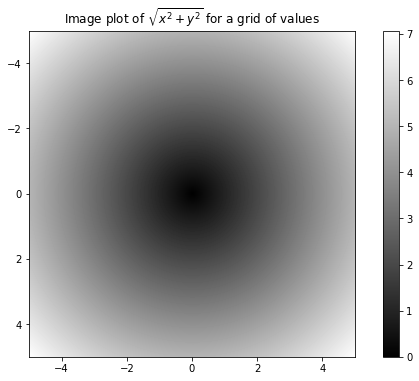

In [94]:
extent=[-5, 5, 5, -5] # ดูมาจาก https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html

import matplotlib.pyplot as plt
plt.imshow(z, cmap=plt.cm.gray, extent=extent); plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

In [95]:
plt.draw()

<Figure size 720x432 with 0 Axes>

In [96]:
plt.close('all')

### Expressing Conditional Logic as Array Operations

In [97]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

In [98]:
result = [(x if c else y)
          for x, y, c in zip(xarr, yarr, cond)]
result

[1.1, 2.2, 1.3, 1.4, 2.5]

In [99]:
result = np.where(cond, xarr, yarr)
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

In [100]:
arr = np.random.randn(4, 4)
arr
arr > 0
np.where(arr > 0, 2, -2)

array([[-2, -2, -2, -2],
       [ 2,  2, -2,  2],
       [ 2,  2,  2, -2],
       [ 2, -2,  2,  2]])

In [101]:
np.where(arr > 0, 2, arr) # set only positive values to 2

array([[-0.5031, -0.6223, -0.9212, -0.7262],
       [ 2.    ,  2.    , -1.1577,  2.    ],
       [ 2.    ,  2.    ,  2.    , -0.9975],
       [ 2.    , -0.1316,  2.    ,  2.    ]])

### Mathematical and Statistical Methods

In [102]:
arr = np.random.randn(5, 4)
arr
arr.mean()
np.mean(arr)
arr.sum()

3.9214102239996507

In [103]:
arr.mean(axis=1)
arr.sum(axis=0)

array([ 3.1693, -2.6345,  2.2381,  1.1486])

In [104]:
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7])
arr.cumsum()

array([ 0,  1,  3,  6, 10, 15, 21, 28], dtype=int32)

`arr.mean(1)` means “compute mean across the columns” where `arr.sum(0)`
means “compute sum down the rows.”

In [105]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
print(f"arr=\n{arr}")
print(f"cumsum(axis=0)=\n{arr.cumsum(axis=0)}")
print(f"cumprod(axis=1)=\n{arr.cumprod(axis=1)}")

arr=
[[0 1 2]
 [3 4 5]
 [6 7 8]]
cumsum(axis=0)=
[[ 0  1  2]
 [ 3  5  7]
 [ 9 12 15]]
cumprod(axis=1)=
[[  0   0   0]
 [  3  12  60]
 [  6  42 336]]


In [106]:
#ลองเอง
my_arr = np.array([[1, 2, 3], [10, 20, 30]])
print(f"arr=\n{my_arr}")
print(f"across rows=\n{my_arr.sum(axis=0)}")
print(f"across columns=\n{my_arr.sum(axis=1)}")

arr=
[[ 1  2  3]
 [10 20 30]]
across rows=
[11 22 33]
across columns=
[ 6 60]


In [107]:
#ลองเอง
my_arr = np.array([[1, 2, 3], [10, 20, 30]])
print(f"arr=\n{my_arr}")
print(f"across rows=\n{my_arr - my_arr.mean(axis=0)}")
print(f"across columns=\n{my_arr - my_arr.mean(axis=1)}")
#ในบรรทัดสุดท้าย array shape (2,) ไม่สามารถ broadcast ไปเป็น (2,3) ได้เพราะว่ามันไม่ถูก pad 1 เข้าทางขวาของ shape ไปเป็น (2,1)
#นี่เป็นเพราะ กฎมีอยู่ว่าในการ pad 1 จะเข้าทางซ้ายเสมอ

arr=
[[ 1  2  3]
 [10 20 30]]
across rows=
[[ -4.5  -9.  -13.5]
 [  4.5   9.   13.5]]


ValueError: operands could not be broadcast together with shapes (2,3) (2,) 

**เพิ่มเติม** <br/> 
ดูยังไงว่า ต้อง เป้น (2,1) ถึงจะ compatible กับ (2,3) คำตอบก็คือให้ลองคิดว่า ถ้า aggregate เสร็จแล้วยังไม่ แปลง array ผลลัพธ์ให้เป็น lower dimension shape ของ array ดังกล่าวก็จะ compatible กับ shape ของ original array

![](chan_folder/agg_broadcast_edited.png)

In [ ]:
#ลองเอง
print(f"across columns=\n{my_arr - my_arr.mean(axis=1)[:, np.newaxis]}")

### Methods for Boolean Arrays

In [ ]:
arr = np.random.randn(100)
(arr > 0).sum() # Number of positive values

In [ ]:
#From book:
# These methods also work with non-boolean arrays, where non-zero elements evaluate
# to True.

bools = np.array([False, False, True, False])
print(bools.any())
print(bools.all())

### Sorting

In [ ]:
arr = np.random.randn(6)
print(arr)
arr.sort()
arr

In [ ]:
#arr = np.random.randn(5, 3)
arr = np.array([[15, 14, 11], [9, 6, 3]])
print(arr)
arr.sort(1)
print(f"across columns=\n{arr}")
arr.sort(0)
print(f"across rows=\n{arr}")

In [ ]:
large_arr = np.random.randn(1000)
large_arr.sort()
large_arr[int(0.05 * len(large_arr))] # 5% quantile

In [ ]:
np.random.randn?

### Unique and Other Set Logic

NumPy has some basic set operations for **one-dimensional ndarrays**. A commonly
used one is `np.unique`, which returns the sorted unique values in an array:

In [ ]:
names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])
print(np.unique(names))
ints = np.array([3, 3, 3, 2, 2, 1, 1, 4, 4])
print(np.unique(ints))

In [ ]:
np.unique(names)

In [ ]:
sorted(set(names))

In [ ]:
values = np.array([6, 0, 0, 3, 2, 5, 6])
np.in1d(values, [2, 3, 6])

## File Input and Output with Arrays

In [ ]:
arr = np.arange(10)
np.save('some_array', arr)

In [ ]:
np.load('some_array.npy')

In [ ]:
np.savez('array_archive.npz', a=arr, b=arr)

In [ ]:
arch = np.load('array_archive.npz')
arch['b']

In [ ]:
arch.close()

In [ ]:
np.savez_compressed('arrays_compressed.npz', a=arr, b=arr)

In [ ]:
!del some_array.npy
!del array_archive.npz
!del arrays_compressed.npz

## Linear Algebra

In [ ]:
x = np.array([[1., 2., 3.], [4., 5., 6.]])
y = np.array([[6., 23.], [-1, 7], [8, 9]])
print(f"x=\n{x}")
print(f"y=\n{y}")
x.dot(y)

In [ ]:
np.dot(x, y)

In [ ]:
np.dot(x, np.ones(3))

In [ ]:
x @ np.ones(3)

In [ ]:
#ลองเอง
np.dot(x, np.ones(3)[:, np.newaxis])

In [ ]:
#ลองเอง
x @ np.ones(3)[:, np.newaxis]

In [ ]:
from numpy.linalg import inv, qr
X = np.random.randn(5, 5)
mat = X.T.dot(X)
inv(mat)
print(mat.dot(inv(mat)))
q, r = qr(mat)
print(r)

## Pseudorandom Number Generation

In [ ]:
samples = np.random.normal(size=(4, 4))
samples

In [ ]:
from random import normalvariate
N = 1000000
%timeit samples = [normalvariate(0, 1) for _ in range(N)]
%timeit np.random.normal(size=N)

In [ ]:
np.random.seed(1234)

In [ ]:
rng = np.random.RandomState(1234)
rng.randn(10)

## Example: Random Walks

In [ ]:
#prepare myself
import random
[random.randint(0, 1) for _ in range(10)]

In [ ]:
#prepare myself
'a' if 0 else 'b'

In [ ]:
import random
position = 0
walk = [position]
steps = 1000
for i in range(steps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)

In [ ]:
%matplotlib inline
plt.figure()

In [ ]:
plt.plot(walk[:100])

In [ ]:
np.random.seed(12345)

In [ ]:
nsteps = 1000
draws = np.random.randint(0, 2, size=nsteps)
steps = np.where(draws > 0, 1, -1)
walk = steps.cumsum()

In [ ]:
print(walk.min())
walk.max()

In [ ]:
(np.abs(walk) >= 10).argmax()

Turns out, we can compute
this using argmax, which returns the first index of the maximum value in the
boolean array (`True` is the maximum value)

In [ ]:
#ลองเอง
np.array([0, 1, -1, 5, 4, 2, 5]).argmax()

### Simulating Many Random Walks at Once

In [113]:
nwalks = 5000
nsteps = 1000
draws = np.random.randint(0, 2, size=(nwalks, nsteps)) # 0 or 1
steps = np.where(draws > 0, 1, -1)
walks = steps.cumsum(1)
walks

array([[ -1,  -2,  -3, ...,  26,  27,  28],
       [ -1,   0,   1, ..., -16, -15, -14],
       [  1,   2,   3, ...,  46,  45,  44],
       ...,
       [ -1,   0,  -1, ..., -36, -35, -34],
       [ -1,  -2,  -1, ...,  64,  65,  64],
       [  1,   2,   1, ...,  10,   9,   8]], dtype=int32)

In [114]:
#ลองเอง
print(steps.shape)
my_steps = np.ones_like(steps)
print(my_steps)
my_walks = my_steps.cumsum(1)
print(my_walks)

(5000, 1000)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[   1    2    3 ...  998  999 1000]
 [   1    2    3 ...  998  999 1000]
 [   1    2    3 ...  998  999 1000]
 ...
 [   1    2    3 ...  998  999 1000]
 [   1    2    3 ...  998  999 1000]
 [   1    2    3 ...  998  999 1000]]


In [ ]:
walks.max()
walks.min()

In [ ]:
hits30 = (np.abs(walks) >= 30).any(1)
print(f"{hits30} with shape={hits30.shape}")
hits30.sum() # Number that hit 30 or -30

In [ ]:
#ลองเอง
test_arr = np.array([[False, True, False],
                     [True, False, False]])
print(test_arr.any(0)) # Expect [True, True, False]
print(test_arr.any(1)) # Expect [True, True]

In [ ]:
crossing_times = (np.abs(walks[hits30]) >= 30).argmax(1)
print(crossing_times.shape)
crossing_times.mean()

In [ ]:
crossing_times = (np.abs(walks) >= 30)[hits30].argmax(1) # boolean indexing (using hits30 as a mask) of 2d boolean array
print(crossing_times.shape)
crossing_times.mean()

In [115]:
#ลองเอง
test2_arr = np.array([[False, True, False],
                     [False, False, False],
                     [False, False, True],
                     [False, False, False]])
print(test2_arr.argmax(1))
true_exists = test2_arr.any(1)
true_times = test2_arr[true_exists].argmax(1)
print(true_times)

[1 0 2 0]
[1 2]


In [ ]:
steps = np.random.normal(loc=0, scale=0.25,
                         size=(nwalks, nsteps))

## Conclusion